#### Helpers

In [72]:

import matplotlib.pyplot as plt

def plot_bid_ask_mid(show_df, title):
  plt.figure(figsize=(15, 7))

  plt.scatter(show_df.index, show_df['bid_price_1'], color='seagreen', label='Bid', s=2, alpha=0.6)
  plt.scatter(show_df.index, show_df['ask_price_1'], color='crimson', label='Ask', s=2, alpha=0.6)

  plt.scatter(show_df.index, show_df['bid_price_2'], color='seagreen', label='Ask', s=2, alpha=0.3)
  plt.scatter(show_df.index, show_df['ask_price_2'], color='crimson', label='Ask', s=2, alpha=0.3)

  plt.scatter(show_df.index, show_df['bid_price_3'], color='black', label='Ask', s=2, alpha=0.6)
  plt.scatter(show_df.index, show_df['ask_price_3'], color='black', label='Ask', s=2, alpha=0.6)

  plt.plot(show_df.index, show_df['mid_price'], color='royalblue', label='Mid Price', linewidth=1, alpha=0.8)

  # Formatting
  plt.title(title, fontsize=14)
  plt.xlabel('Index / Time')
  plt.ylabel('Price')
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.legend(markerscale=5) # Makes legend dots bigger so you can see the colors

  plt.tight_layout()
  plt.show()

def plot_trades_on_bid_ask_mid(trades_set, outer_set, window = 3, title = 'Trades over Bid/Mid/Ask Prices'):
  show_df = set()

  for idx in trades_set.index:
    # Find the numeric position (row number) of the match
    try:
      pos = outer_set.index.get_loc(idx)
        
      # Define the window (clamped to ensure we don't go out of bounds)
      start = max(0, pos - window)
      end = min(len(outer_set), pos + window + 1)
        
      # Add these specific index values to our set
      show_df.update(outer_set.index[start:end])
    except KeyError:
      continue # Skip if index isn't in the big DF
  
  show_df = outer_set.loc[sorted(list(show_df))]
  show_df = show_df.join(trades_set[['price']], how='left') # Join the trades data to the show_df for plotting

  plt.figure(figsize=(15, 7))

  plt.scatter(show_df.index, show_df['bid_price_1'], color='seagreen', label='Bid Price 1', s=33, alpha=0.6)
  plt.scatter(show_df.index, show_df['ask_price_1'], color='crimson', label='Ask Price 1', s=33, alpha=0.6)
  plt.scatter(show_df.index, show_df['bid_price_2'], color='yellow', label='Bid Price 2', s=33, alpha=0.3)
  plt.scatter(show_df.index, show_df['ask_price_2'], color='yellow', label='Ask Price 2', s=33, alpha=0.3)
  plt.scatter(show_df.index, show_df['bid_price_3'], color='black', label='Bid Price 3', s=33, alpha=0.3)
  plt.scatter(show_df.index, show_df['ask_price_3'], color='black', label='Ask Price 3', s=33, alpha=0.3)

  plt.scatter(show_df.index, show_df['price'], color='black', label='Trade', s=2, alpha=0.6)
  plt.scatter(show_df.index, show_df['mid_price'], color='royalblue', label='Mid Price', s=2, alpha=0.6)

  plt.xlabel('Timestamp')
  plt.ylabel('Price')
  plt.title(title)
  plt.legend()
  plt.show()

### Visualization

In [73]:
import pandas as pd
import seaborn as sns

# Load the dataset
df = pd.read_csv("ROUND_2/prices_round_2_day_-1.csv", sep=";")
df2 = pd.read_csv("ROUND_2/prices_round_2_day_0.csv", sep=";")
df3 = pd.read_csv("ROUND_2/prices_round_2_day_1.csv", sep=";")


trades = pd.read_csv("ROUND_2/trades_round_2_day_-1.csv", sep=";")
trades2 = pd.read_csv("ROUND_2/trades_round_2_day_0.csv", sep=";")
trades3 = pd.read_csv("ROUND_2/trades_round_2_day_1.csv", sep=";")


# Display the first few rows of the dataset
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   day              20000 non-null  int64  
 1   timestamp        20000 non-null  int64  
 2   product          20000 non-null  str    
 3   bid_price_1      19224 non-null  float64
 4   bid_volume_1     19224 non-null  float64
 5   bid_price_2      13022 non-null  float64
 6   bid_volume_2     13022 non-null  float64
 7   bid_price_3      369 non-null    float64
 8   bid_volume_3     369 non-null    float64
 9   ask_price_1      19200 non-null  float64
 10  ask_volume_1     19200 non-null  float64
 11  ask_price_2      13079 non-null  float64
 12  ask_volume_2     13079 non-null  float64
 13  ask_price_3      401 non-null    float64
 14  ask_volume_3     401 non-null    float64
 15  mid_price        20000 non-null  float64
 16  profit_and_loss  20000 non-null  float64
dtypes: float64(14), int64(2

### PEPPER

In [74]:
# GET PEPPER ROOT DATA

# print(df['product'].unique())

pepper_df = df[df['product'] == 'INTARIAN_PEPPER_ROOT']
pepper_df_2 = df2[df2['product'] == 'INTARIAN_PEPPER_ROOT']
pepper_df_3 = df3[df3['product'] == 'INTARIAN_PEPPER_ROOT']

pepper_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT']
pepper_trades_2 = trades2[trades2['symbol'] == 'INTARIAN_PEPPER_ROOT']
pepper_trades_3 = trades3[trades3['symbol'] == 'INTARIAN_PEPPER_ROOT']

# pepper_df.info()

pepper_df.set_index('timestamp', inplace=True)
pepper_df_2.set_index('timestamp', inplace=True)
pepper_df_3.set_index('timestamp', inplace=True)

pepper_trades.set_index('timestamp', inplace=True)
pepper_trades_2.set_index('timestamp', inplace=True)
pepper_trades_3.set_index('timestamp', inplace=True)

# No trading data for pepper root, all mid prices are 0.01 or less
print((pepper_df['mid_price'] <= 0.01).sum())
print((pepper_df_2['mid_price'] <= 0.01).sum())
print((pepper_df_3['mid_price'] <= 0.01).sum())


#drop the rows with mid_price <= 0.01
pepper_df = pepper_df[pepper_df['mid_price'] > 0.01]
pepper_df_2 = pepper_df_2[pepper_df_2['mid_price'] > 0.01]
pepper_df_3 = pepper_df_3[pepper_df_3['mid_price'] > 0.01]

13
18
16


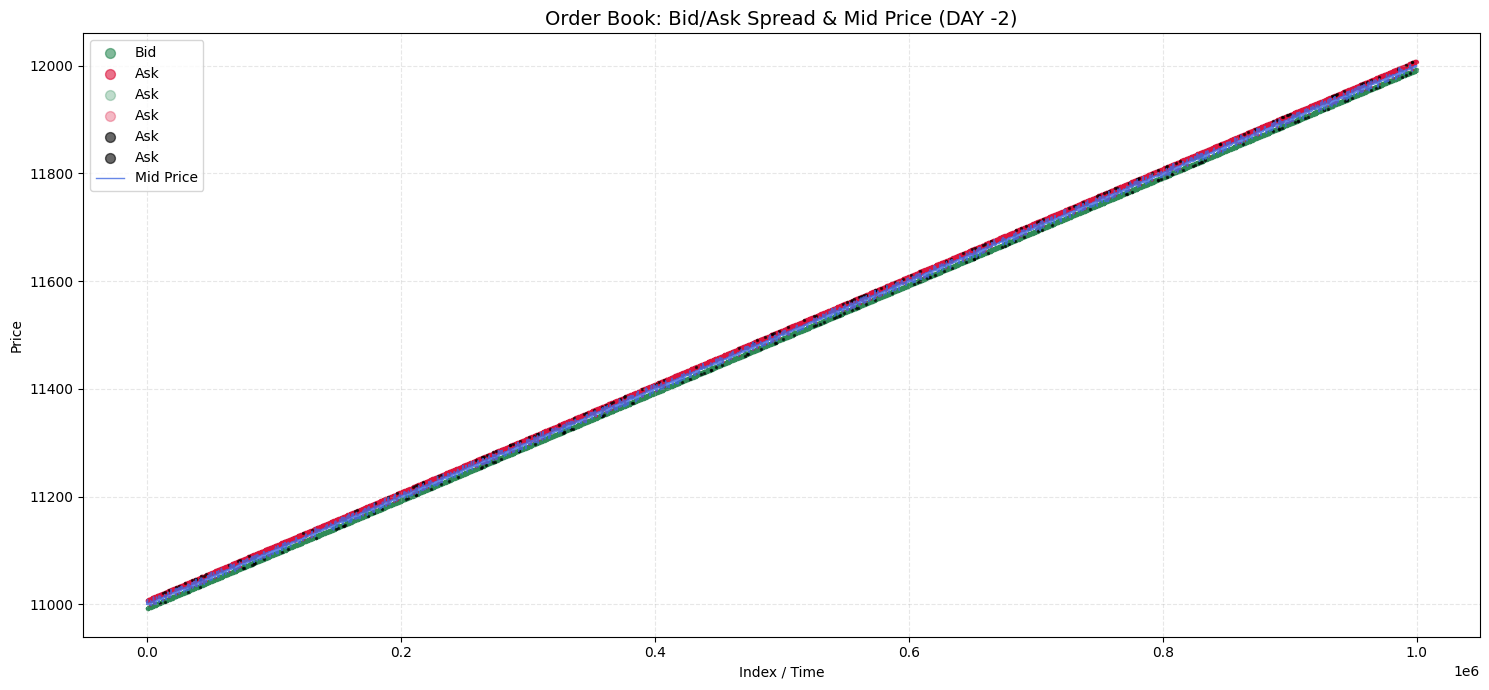

In [75]:
show_df = pepper_df[:] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -2)")

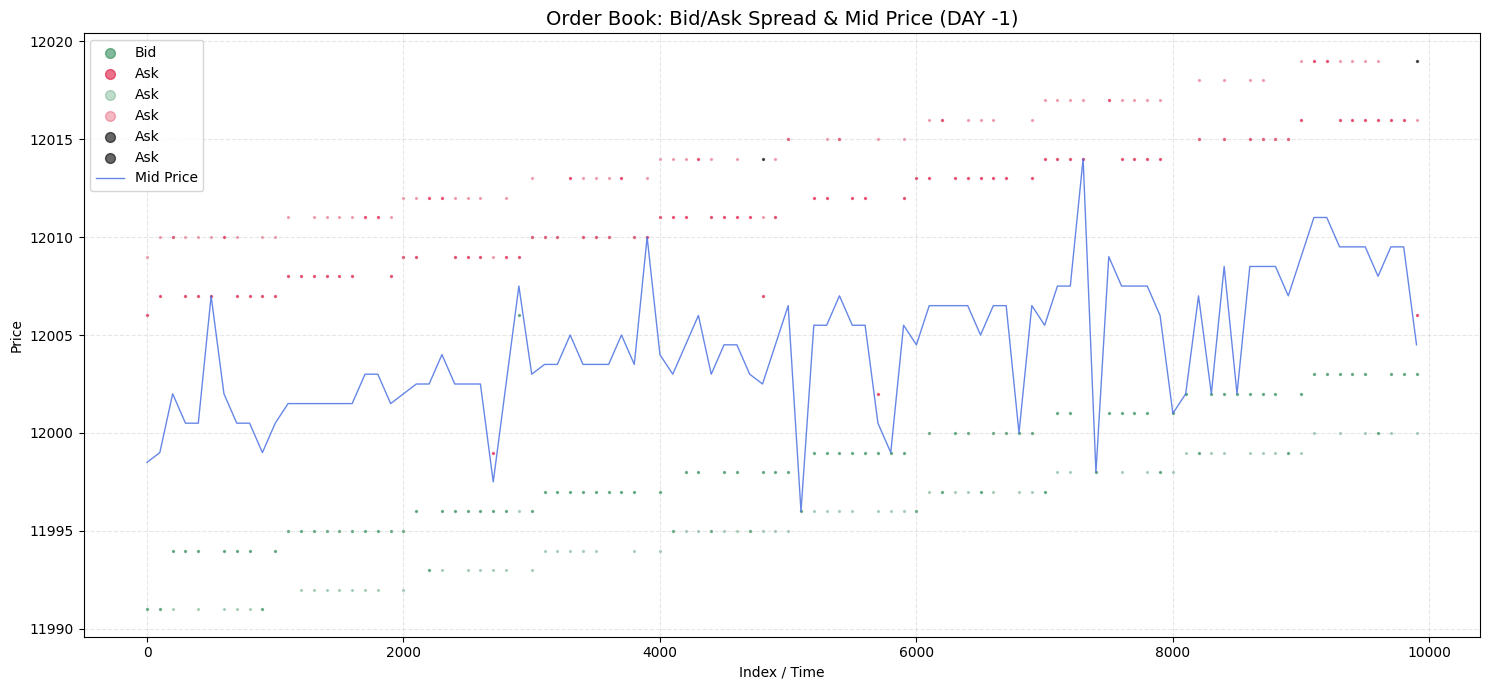

In [76]:
show_df = pepper_df_2[:100] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -1)")

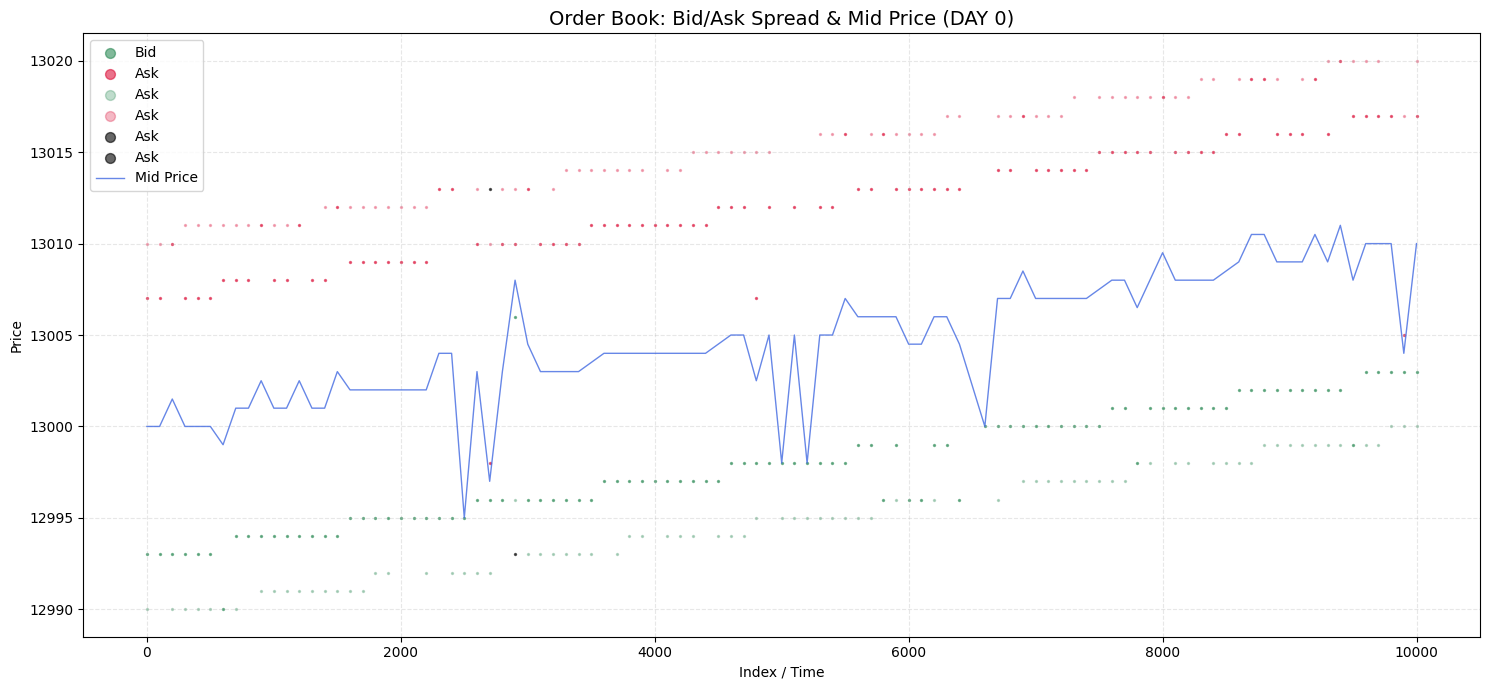

In [77]:
show_df = pepper_df_3[:100] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY 0)")

#### Mid-price vs Trades

In [78]:
# match the trades with the order book data and plot the trades on top of the bid/ask spread

midtrade_df = pepper_df_2.join(pepper_trades_2, how='inner') # Control the days to show trades for by changing the dataframes here
show_df = midtrade_df[8:10] # Controls how many trades to show on the plot (around 400 trades in total)

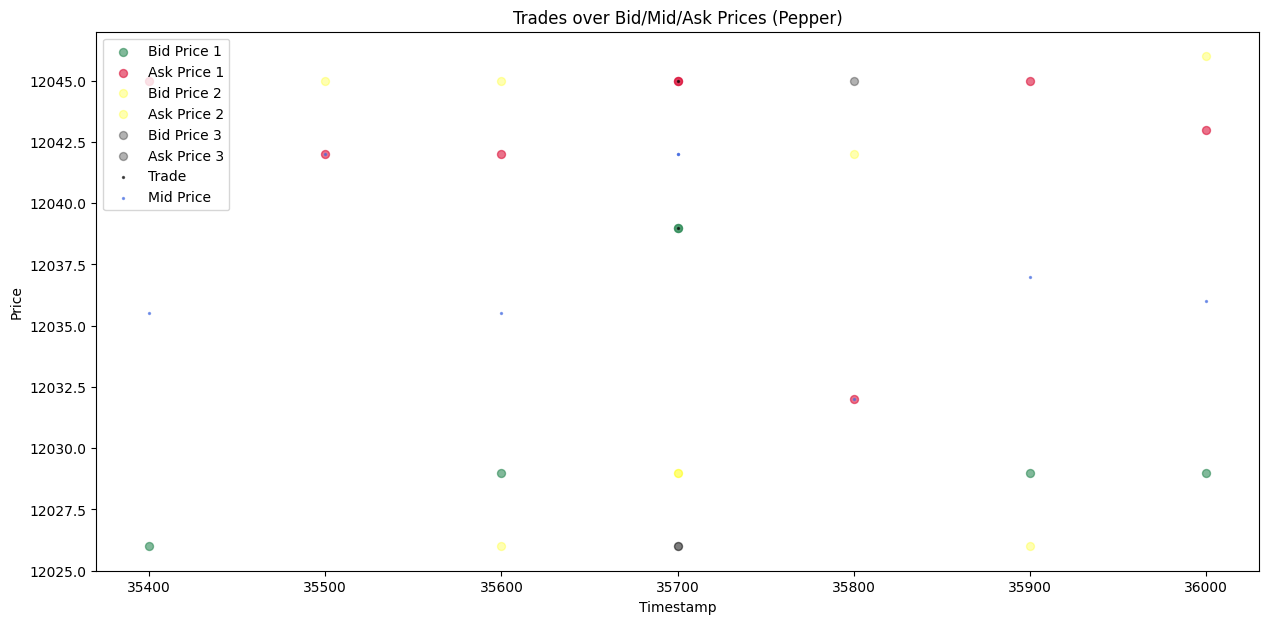

In [79]:
plot_trades_on_bid_ask_mid(show_df, pepper_df_2, window=3, title='Trades over Bid/Mid/Ask Prices (Pepper)')


### OSMIUM

In [80]:
# GET OSMIUM DATA

osmium_df = df[df['product'] == 'ASH_COATED_OSMIUM']

# print(df['product'].unique())

osmium_df = df[df['product'] == 'ASH_COATED_OSMIUM']
osmium_df_2 = df2[df2['product'] == 'ASH_COATED_OSMIUM']
osmium_df_3 = df3[df3['product'] == 'ASH_COATED_OSMIUM']

osmium_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM']
osmium_trades_2 = trades2[trades2['symbol'] == 'ASH_COATED_OSMIUM']
osmium_trades_3 = trades3[trades3['symbol'] == 'ASH_COATED_OSMIUM']

# osmium_df.info()

osmium_df.set_index('timestamp', inplace=True)
osmium_df_2.set_index('timestamp', inplace=True)
osmium_df_3.set_index('timestamp', inplace=True)

osmium_trades.set_index('timestamp', inplace=True)
osmium_trades_2.set_index('timestamp', inplace=True)
osmium_trades_3.set_index('timestamp', inplace=True)

# No trading data for osmium, all mid prices are 0.01 or less
print((osmium_df['mid_price'] <= 0.01).sum())
print((osmium_df_2['mid_price'] <= 0.01).sum())
print((osmium_df_3['mid_price'] <= 0.01).sum())


#drop the rows with mid_price <= 0.01
osmium_df = osmium_df[osmium_df['mid_price'] > 0.01]
osmium_df_2 = osmium_df_2[osmium_df_2['mid_price'] > 0.01]
osmium_df_3 = osmium_df_3[osmium_df_3['mid_price'] > 0.01]

15
16
22


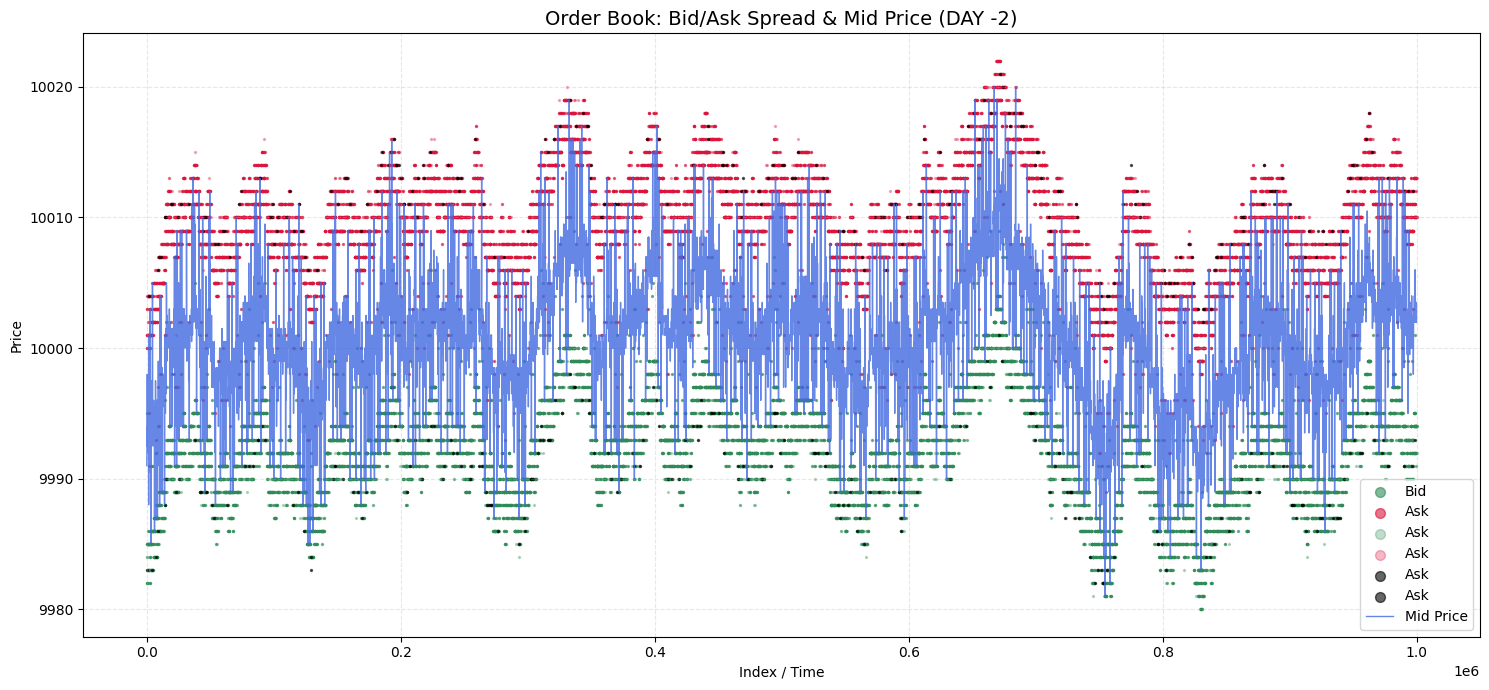

In [81]:
show_df = osmium_df[0:10000] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -2)")

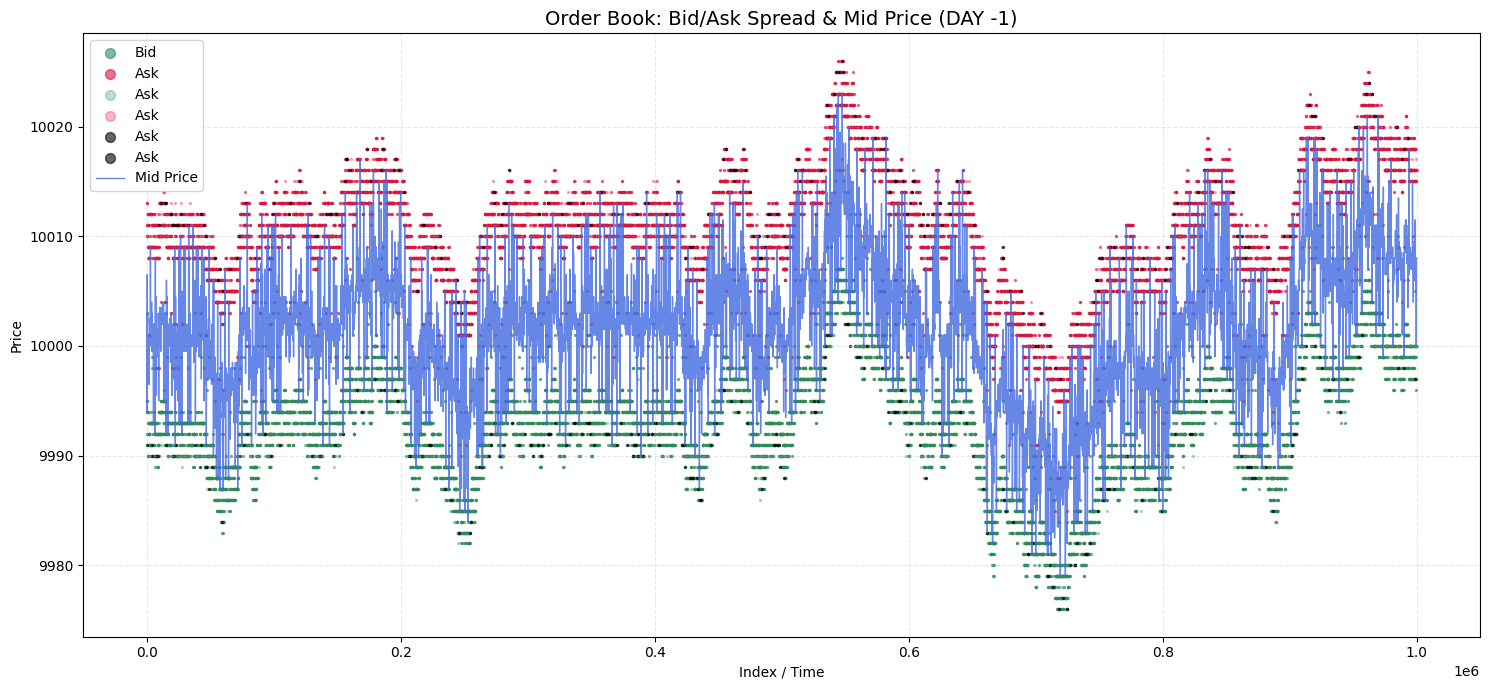

In [82]:
show_df = osmium_df_2[0:10000] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY -1)")

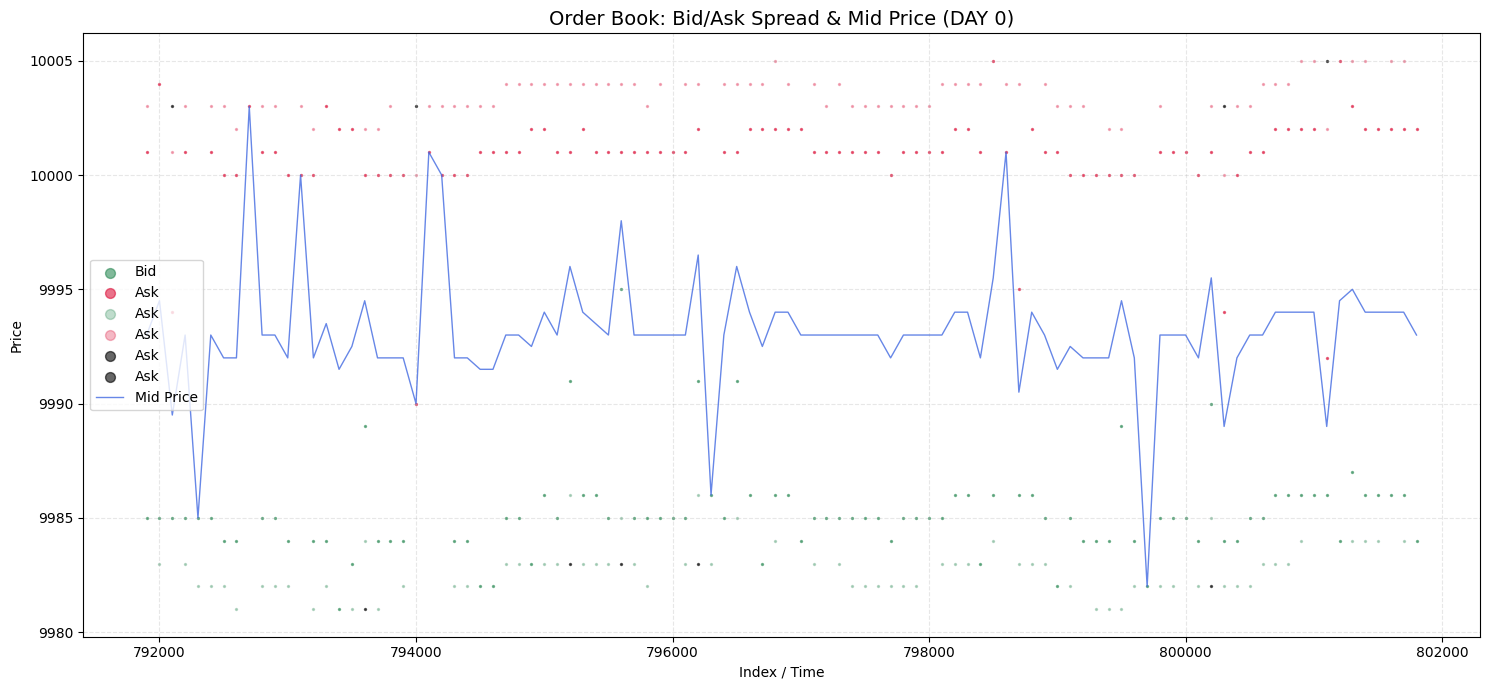

In [83]:
show_df = osmium_df_3[7900:8000] # Show only the last 1000 rows for better visibility
plot_bid_ask_mid(show_df, "Order Book: Bid/Ask Spread & Mid Price (DAY 0)")

### Mid-price vs Trades

In [84]:
# match the trades with the order book data and plot the trades on top of the bid/ask spread

midtrade_df = osmium_df.join(osmium_trades, how='inner') # Control the days to show trades for by changing the dataframes here
show_df = midtrade_df[300:330] # Controls how many trades to show on the plot (around 400 trades in total)

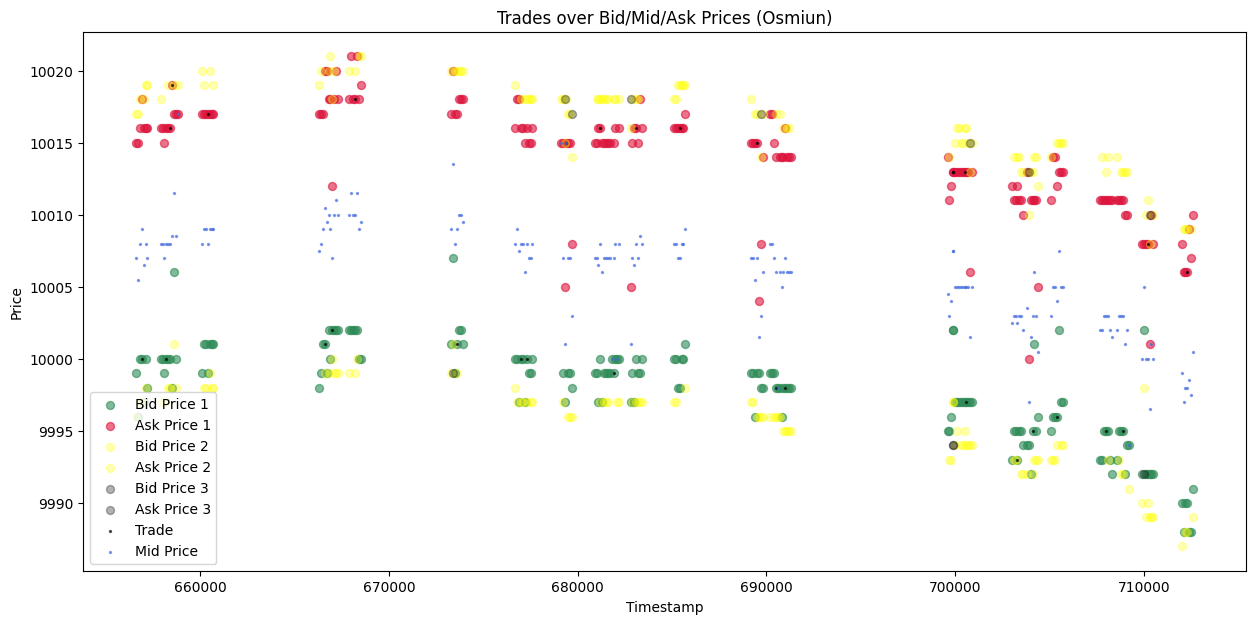

In [85]:
plot_trades_on_bid_ask_mid(show_df, osmium_df, window=3, title='Trades over Bid/Mid/Ask Prices (Osmiun)')

### Volume Analysis

#### Pepper

# Day -2 volume
	 - Total volume traded:  1669
	 - Max volume traded:  8
	 - Min volume traded:  3
	 - Average volume traded:  5.042296072507553
# Day -1 volume
	 - Total volume traded:  1671
	 - Max volume traded:  8
	 - Min volume traded:  3
	 - Average volume traded:  5.033132530120482
# Day 0 volume
	 - Total volume traded:  1693
	 - Max volume traded:  8
	 - Min volume traded:  3
	 - Average volume traded:  5.084084084084084


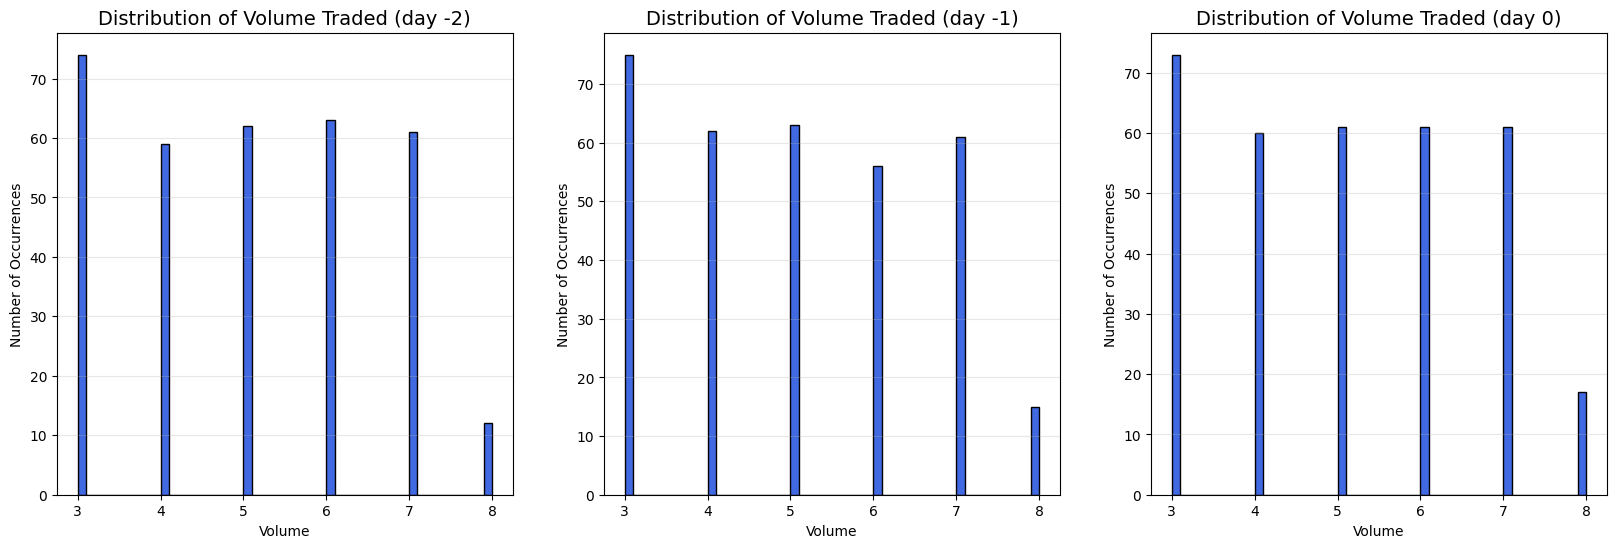

In [86]:
print("# Day -2 volume")
print("\t - Total volume traded: ", pepper_trades['quantity'].sum())
print("\t - Max volume traded: ", pepper_trades['quantity'].max())
print("\t - Min volume traded: ", pepper_trades['quantity'].min())
print("\t - Average volume traded: ", pepper_trades['quantity'].mean())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.hist(pepper_trades['quantity'].dropna(), bins=50, color='royalblue', edgecolor='black')

ax1.set_title('Distribution of Volume Traded (day -2)', fontsize=14)
ax1.set_xlabel('Volume')
ax1.set_ylabel('Number of Occurrences')
ax1.grid(axis='y', alpha=0.3)

print("# Day -1 volume")
print("\t - Total volume traded: ", pepper_trades_2['quantity'].sum())
print("\t - Max volume traded: ", pepper_trades_2['quantity'].max())
print("\t - Min volume traded: ", pepper_trades_2['quantity'].min())
print("\t - Average volume traded: ", pepper_trades_2['quantity'].mean())

ax2.hist(pepper_trades_2['quantity'].dropna(), bins=50, color='royalblue', edgecolor='black')

ax2.set_title('Distribution of Volume Traded (day -1)', fontsize=14)
ax2.set_xlabel('Volume')
ax2.set_ylabel('Number of Occurrences')
ax2.grid(axis='y', alpha=0.3)

print("# Day 0 volume")
print("\t - Total volume traded: ", pepper_trades_3['quantity'].sum())
print("\t - Max volume traded: ", pepper_trades_3['quantity'].max())
print("\t - Min volume traded: ", pepper_trades_3['quantity'].min())
print("\t - Average volume traded: ", pepper_trades_3['quantity'].mean())

ax3.hist(pepper_trades_3['quantity'].dropna(), bins=50, color='royalblue', edgecolor='black')

ax3.set_title('Distribution of Volume Traded (day 0)', fontsize=14)
ax3.set_xlabel('Volume')
ax3.set_ylabel('Number of Occurrences')
ax3.grid(axis='y', alpha=0.3)

plt.show()



#### Product

# Day -2 volume
	 - Total volume traded:  2348
	 - Max volume traded:  10
	 - Min volume traded:  2
	 - Average volume traded:  5.1154684095860565
# Day -1 volume
	 - Total volume traded:  2404
	 - Max volume traded:  10
	 - Min volume traded:  2
	 - Average volume traded:  5.104033970276008
# Day 0 volume
	 - Total volume traded:  2375
	 - Max volume traded:  10
	 - Min volume traded:  2
	 - Average volume traded:  5.10752688172043


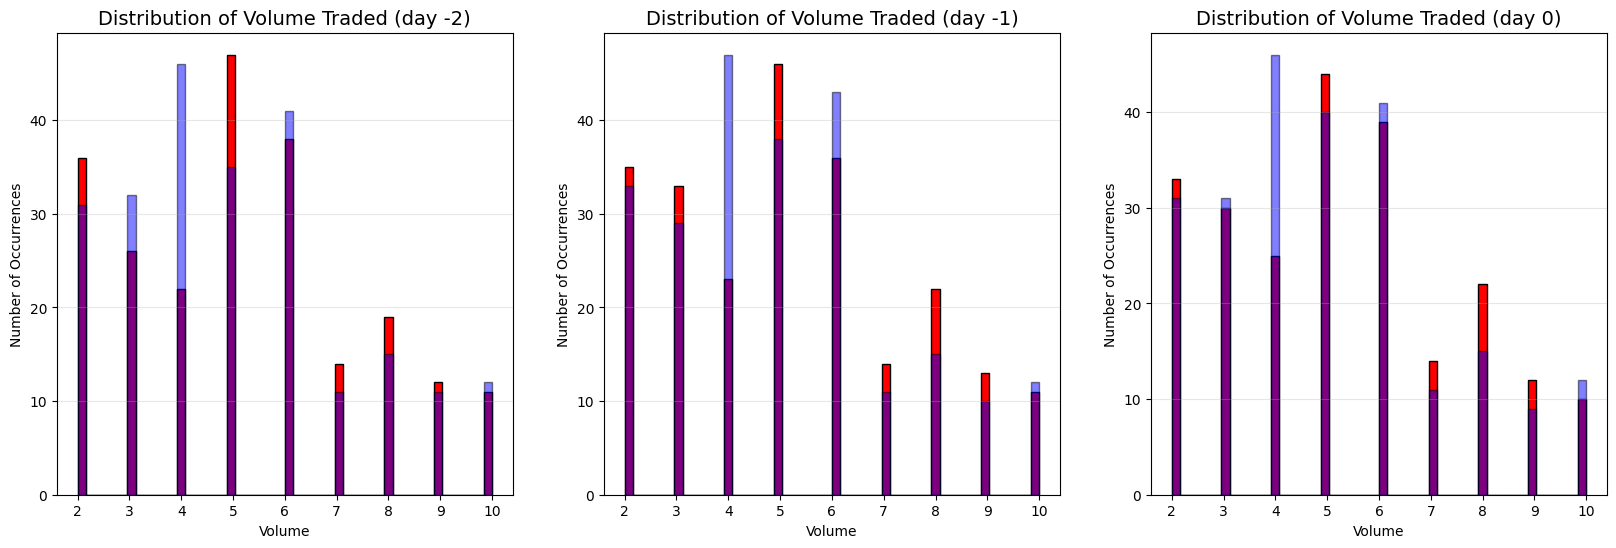

In [87]:
print("# Day -2 volume")
print("\t - Total volume traded: ", osmium_trades['quantity'].sum())
print("\t - Max volume traded: ", osmium_trades['quantity'].max())
print("\t - Min volume traded: ", osmium_trades['quantity'].min())
print("\t - Average volume traded: ", osmium_trades['quantity'].mean())

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Products trades where price == ask_price_0
osmium_trades_ask = midtrade_df[midtrade_df['price'] == midtrade_df['ask_price_1']]
# Product trades where price == bid_price_0
osmium_trades_bid = midtrade_df[midtrade_df['price'] == midtrade_df['bid_price_1']]

ax1.hist(osmium_trades_ask['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax1.hist(osmium_trades_bid['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax1.set_title('Distribution of Volume Traded (day -2)', fontsize=14)
ax1.set_xlabel('Volume')
ax1.set_ylabel('Number of Occurrences')
ax1.grid(axis='y', alpha=0.3)

midtrade_df_2 = osmium_df_2.join(osmium_trades_2, how='inner') # Control the days to show trades for by changing the dataframes here

# Products trades where price == ask_price_0
osmium_trades_ask_2 = midtrade_df_2[midtrade_df_2['price'] == midtrade_df_2['ask_price_1']]
# Product trades where price == bid_price_0
osmium_trades_bid_2 = midtrade_df_2[midtrade_df_2['price'] == midtrade_df_2['bid_price_1']]

print("# Day -1 volume")
print("\t - Total volume traded: ", osmium_trades_2['quantity'].sum())
print("\t - Max volume traded: ", osmium_trades_2['quantity'].max())
print("\t - Min volume traded: ", osmium_trades_2['quantity'].min())
print("\t - Average volume traded: ", osmium_trades_2['quantity'].mean())

ax2.hist(osmium_trades_ask_2['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax2.hist(osmium_trades_bid_2['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax2.set_title('Distribution of Volume Traded (day -1)', fontsize=14)
ax2.set_xlabel('Volume')
ax2.set_ylabel('Number of Occurrences')
ax2.grid(axis='y', alpha=0.3)

print("# Day 0 volume")
print("\t - Total volume traded: ", osmium_trades_3['quantity'].sum())
print("\t - Max volume traded: ", osmium_trades_3['quantity'].max())
print("\t - Min volume traded: ", osmium_trades_3['quantity'].min())
print("\t - Average volume traded: ", osmium_trades_3['quantity'].mean())

midtrade_df_3 = osmium_df_3.join(osmium_trades_3, how='inner') # Control the days to show trades for by changing the dataframes here 
# Products trades where price == ask_price_0
osmium_trades_ask_3 = midtrade_df_3[midtrade_df_3['price'] == midtrade_df_3['ask_price_1']]
# Product trades where price == bid_price_0
osmium_trades_bid_3 = midtrade_df_3[midtrade_df_3['price'] == midtrade_df_3['bid_price_1']]

ax3.hist(osmium_trades_ask_3['quantity'].dropna(), bins=50, color='red', edgecolor='black')
ax3.hist(osmium_trades_bid_3['quantity'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.5)

ax3.set_title('Distribution of Volume Traded (day 0)', fontsize=14)
ax3.set_xlabel('Volume')
ax3.set_ylabel('Number of Occurrences')
ax3.grid(axis='y', alpha=0.3)

plt.show()



Average spread:  16.223990473097327


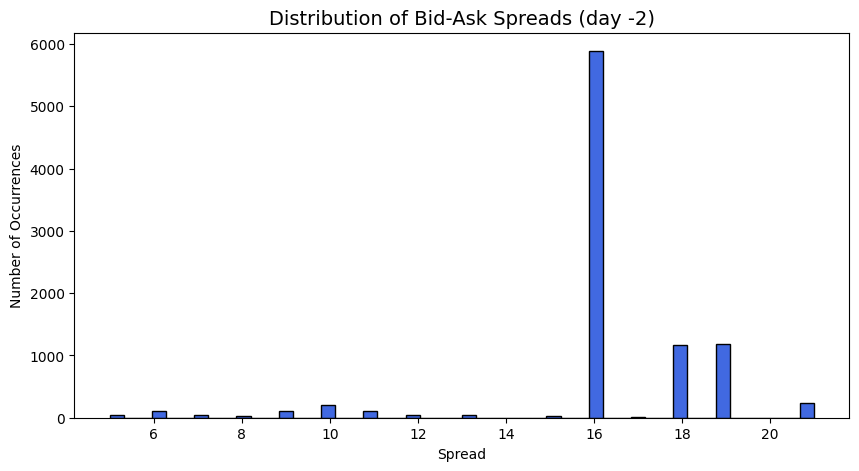

In [88]:
spread = osmium_df['ask_price_1'] - osmium_df['bid_price_1']
print("Average spread: ", spread.mean())

# Show histogram of spreads
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day -2)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()

Average spread:  16.249540887976668


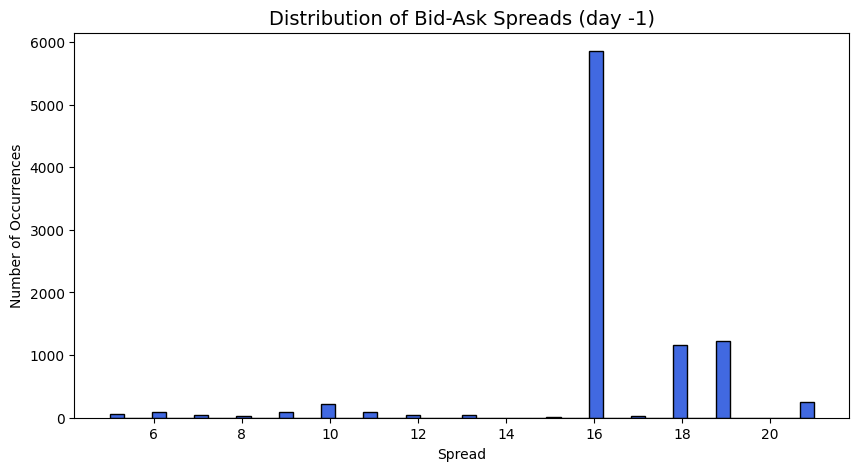

In [89]:
spread = osmium_df_2['ask_price_1'] - osmium_df_2['bid_price_1']
print("Average spread: ", spread.mean()) 

plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()


Average spread:  16.228890818319947


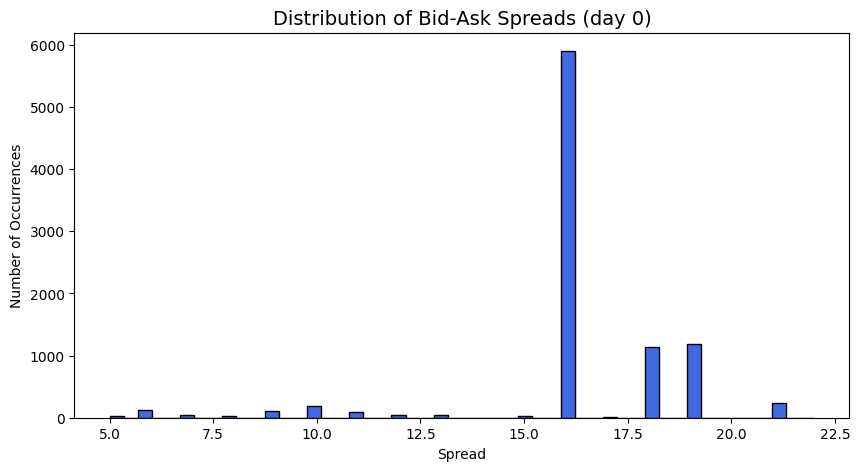

In [90]:
spread = osmium_df_3['ask_price_1'] - osmium_df_3['bid_price_1']
print("Average spread: ", spread.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads (day 0)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Number of Occurrences')
plt.show()


Average spread for trades:  16.355855855855857


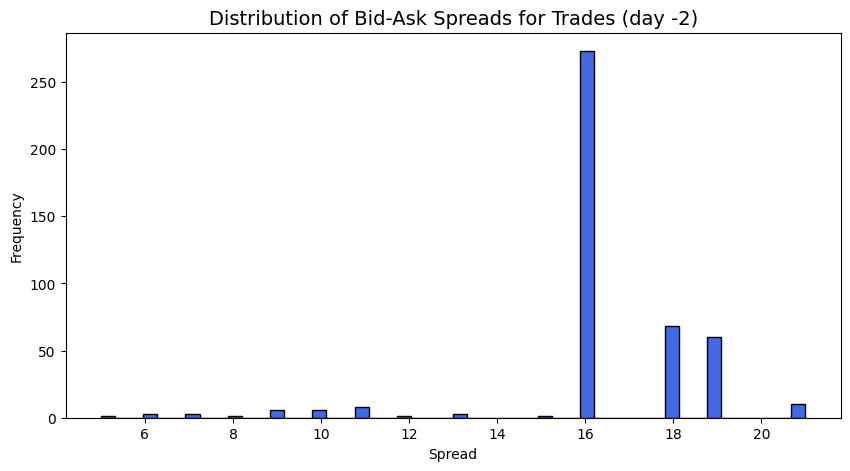

In [91]:
spread = midtrade_df['ask_price_1'] - midtrade_df['bid_price_1']
print("Average spread for trades: ", spread.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -2)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

Average spread for trades:  16.14


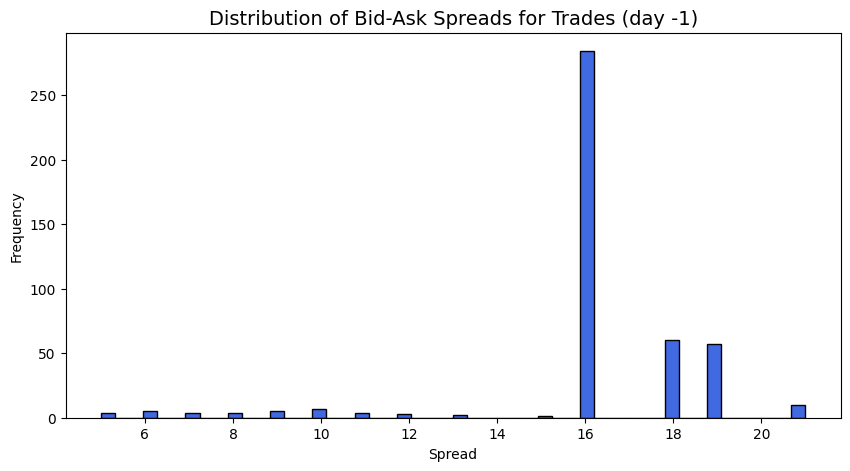

In [92]:
spread = midtrade_df_2['ask_price_1'] - midtrade_df_2['bid_price_1']
print("Average spread for trades: ", spread.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

Average spread for trades:  16.06053811659193


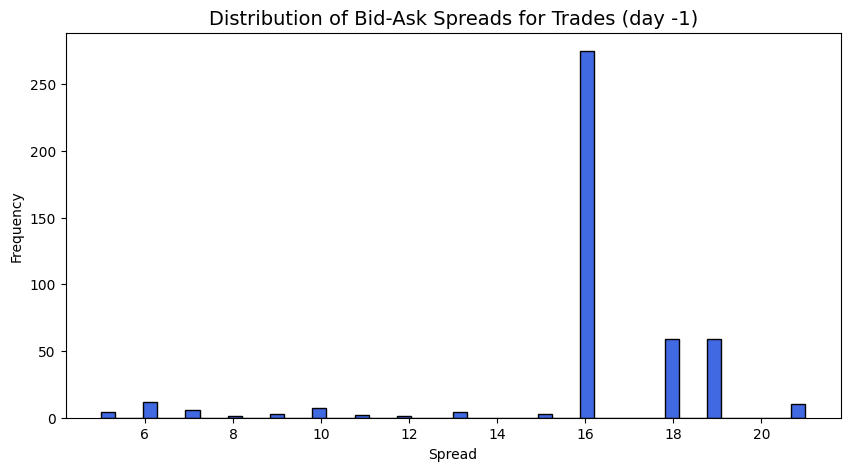

In [93]:
spread = midtrade_df_3['ask_price_1'] - midtrade_df_3['bid_price_1']
print("Average spread for trades: ", spread.mean())
plt.figure(figsize=(10, 5))
plt.hist(spread.dropna(), bins=50, color='royalblue', edgecolor='black')
plt.title('Distribution of Bid-Ask Spreads for Trades (day -1)', fontsize=14)
plt.xlabel('Spread')
plt.ylabel('Frequency')
plt.show()

In [94]:
max_time = df['timestamp'].max()
min_time = df['timestamp'].min()

# 3. Apply the reverse mapping
# Formula: NewTime = MaxTime - CurrentTime + MinTime
df['timestamp'] = max_time - df['timestamp'] + min_time

# 4. Sort and Save
df = df.sort_values(by='timestamp')
df.to_csv('time_swapped_data.csv', index=False)

In [96]:
max_time = trades['timestamp'].max()
min_time = trades['timestamp'].min()

# 3. Apply the reverse mapping
# Formula: NewTime = MaxTime - CurrentTime + MinTime
trades['timestamp'] = max_time - trades['timestamp'] + min_time

# 4. Sort and Save
trades = trades.sort_values(by='timestamp')
trades.to_csv('time_swapped_data.csv', index=False)